In [ ]:
# Snapshot Analysis of Transient Synaptic Memory
'''
This notebook analyzes the output of a **single realization** of the transient synaptic memory model.

It reproduces the snapshot analysis presented in the paper, including:

- Network activity
- Potential reactivation histograms
- Ghost neurons
- Fresh neurons
'''

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec

In [2]:
###########################################################
# User parameters
###########################################################

R = 1

DATA_DIR = "../sample_output/single_run"

###########################################################
# Model parameters
###########################################################

N = 2000

E = 0.8

N_E = int(N * E)

D = 5

TE = 5

TI = 7

WE = 1

WI = -4

eta = 0.02

###########################################################
# Plot parameters
###########################################################

fs = 14

ms = 7

In [3]:
def H(x):
    return int(x > 0)

In [6]:
###########################################################
# Load activity data
###########################################################

activity = np.loadtxt(
    f"{DATA_DIR}/ActivityInTime_{R}.txt"
)

time  = activity[:, 0]
rho   = activity[:, 1]
phiE  = activity[:, 2]
phiI  = activity[:, 3]

phi = phiE + phiI

t_max = len(time)

# first extinction time
tz = np.argmax(rho == 0)

###########################################################
# Active neurons
###########################################################

active_nodes_t = []

with open(f"{DATA_DIR}/ActiveNodesInTime_{R}.txt") as f:

    for line in f:

        row = np.fromstring(
            line,
            sep=' ',
            dtype=int
        )

        active_nodes_t.append(row[1:])

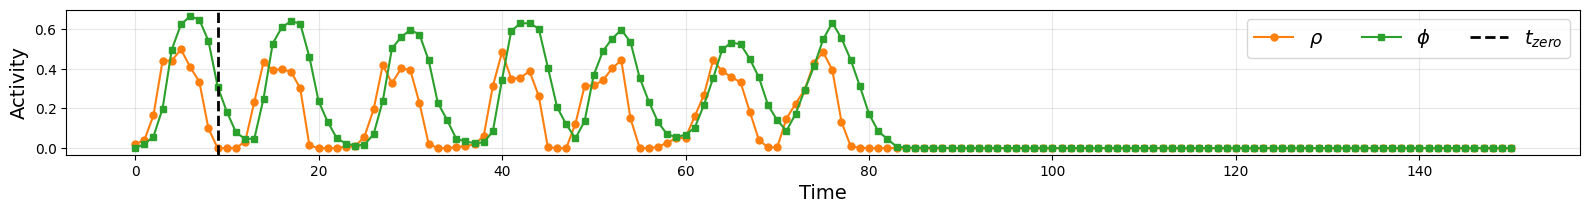

In [14]:
###########################################################
# Create figure
###########################################################

fig = plt.figure(
    figsize=(16, 8),
    facecolor="white"
)

gs = GridSpec(8, 16)

###########################################################
# Activity
###########################################################

ax = fig.add_subplot(gs[0:2, :])

ax.plot(
    time,
    rho,
    "-o",
    color="C1",
    ms=ms-2,
    label=r"$\rho$"
)

ax.plot(
    time,
    phi,
    "-s",
    color="C2",
    ms=ms-2,
    label=r"$\phi$"
)

ax.axvline(
    tz,
    color="k",
    lw=2,
    ls="--",
    label=r"$t_{zero}$"
)

ax.set_xlabel(
    "Time",
    fontsize=fs
)

ax.set_ylabel(
    "Activity",
    fontsize=fs
)

ax.grid(alpha=0.3)

ax.legend(
    fontsize=fs,
    ncol=3
)

plt.tight_layout()

plt.savefig(
    "RhoPhi.pdf",
    bbox_inches="tight"
)

plt.show()

In [8]:
###########################################################
# Load snapshot data
###########################################################

#----------------------------------------------------------
# Potential reactivation
#----------------------------------------------------------

potential = np.loadtxt(
    f"{DATA_DIR}/PotentialReactivation_{R}.txt"
)

tau_values = potential[:, 0].astype(int)

tau_max = tau_values.max()

#----------------------------------------------------------
# Active neurons at each tau
#----------------------------------------------------------

active_nodes_tau = []

with open(f"{DATA_DIR}/ActiveNodesInTau_{R}.txt") as f:

    for line in f:

        row = np.fromstring(
            line,
            sep=' ',
            dtype=int
        )

        active_nodes_tau.append(row[1:])

#----------------------------------------------------------
# Ghost neurons
#----------------------------------------------------------

ghost_nodes_tau = []

with open(f"{DATA_DIR}/GhostNodesInTau_{R}.txt") as f:

    for line in f:

        row = np.fromstring(
            line,
            sep=' ',
            dtype=int
        )

        ghost_nodes_tau.append(row[1:])

In [9]:
###########################################################
# Compute active / ghost / fresh neurons
###########################################################

N_E_active = np.zeros(tau_max + 1, dtype=int)
N_I_active = np.zeros(tau_max + 1, dtype=int)

N_E_fresh = np.zeros(tau_max + 1, dtype=int)
N_I_fresh = np.zeros(tau_max + 1, dtype=int)

fresh_nodes_tau = []

for tau in range(tau_max + 1):

    active = active_nodes_tau[tau]

    ghost = ghost_nodes_tau[tau]

    fresh = np.setdiff1d(
        active,
        ghost
    )

    fresh_nodes_tau.append(fresh)

    #-----------------------------
    # Active neurons
    #-----------------------------

    N_E_active[tau] = np.sum(active < N_E)

    N_I_active[tau] = np.sum(active >= N_E)

    #-----------------------------
    # Fresh neurons
    #-----------------------------

    N_E_fresh[tau] = np.sum(fresh < N_E)

    N_I_fresh[tau] = np.sum(fresh >= N_E)

###########################################################
# Ghost neurons
###########################################################

N_E_ghost = N_E_active - N_E_fresh

N_I_ghost = N_I_active - N_I_fresh

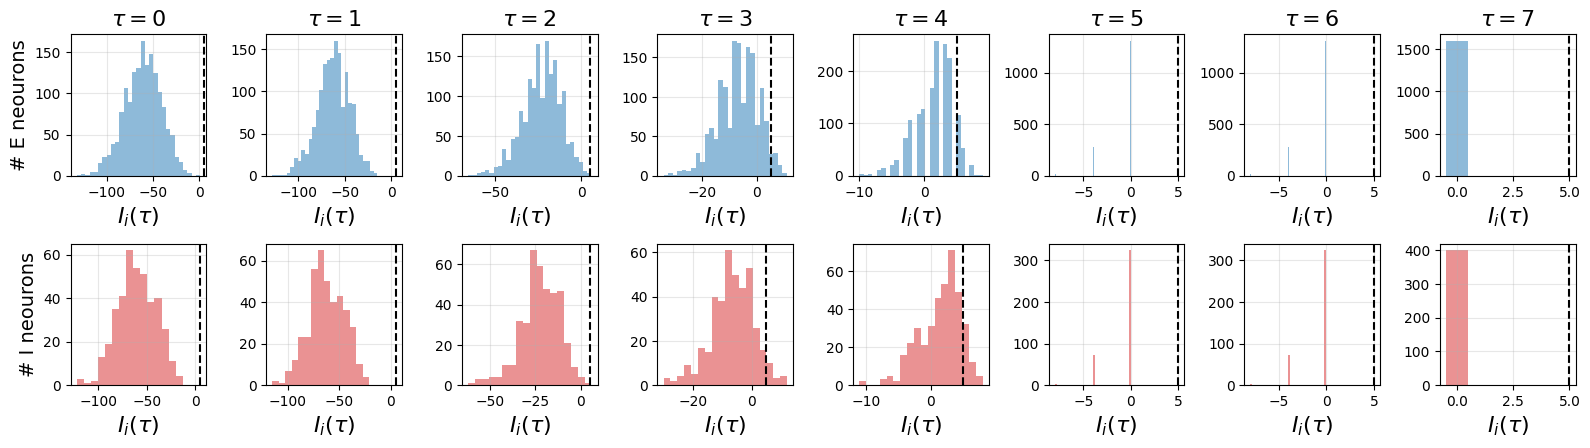

In [16]:
###########################################################
# Plot potential reactivation histograms
###########################################################

#----------------------------------------------------------
# Create figure
#----------------------------------------------------------

fig = plt.figure(
    figsize=(16, 8),
    facecolor="white"
)

gs = GridSpec(8, 16)

#----------------------------------------------------------
# Excitatory neurons
#----------------------------------------------------------

for tau in range(tau_max + 1):

    ax = fig.add_subplot(
        gs[2:4, 2*tau : 2*(tau+1)]
    )

    ax.hist(
        potential[tau, 1:N_E+1],
        bins="auto",
        color="C0",
        alpha=0.5
    )

    ax.axvline(
        D,
        color="k",
        ls="--"
    )

    ax.grid(alpha=0.3)

    ax.set_title(
        rf"$\tau={tau}$",
        fontsize=fs+2
    )

    plt.xlabel(r'$I_i(\tau)$',fontsize=fs+2)
    if tau==0:
        plt.ylabel('# E neourons',fontsize=fs)

#----------------------------------------------------------
# Inhibitory neurons
#----------------------------------------------------------

for tau in range(tau_max + 1):

    ax = fig.add_subplot(
        gs[4:6, 2*tau : 2*(tau+1)]
    )

    ax.hist(
        potential[tau, N_E+1:],
        bins="auto",
        color="C3",
        alpha=0.5
    )

    ax.axvline(
        D,
        color="k",
        ls="--"
    )

    ax.grid(alpha=0.3)

    plt.xlabel(r'$I_i(\tau)$',fontsize=fs+2)
    if tau==0:
        plt.ylabel('# I neourons',fontsize=fs)


plt.tight_layout()

plt.savefig(
    "Histograms.pdf",
    bbox_inches="tight"
)

plt.show()

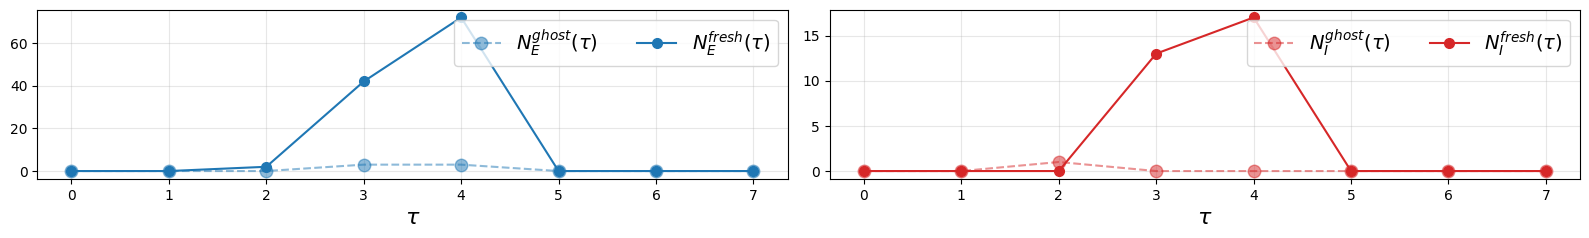

In [13]:
###########################################################
# Plot ghost and fresh neurons
###########################################################

#----------------------------------------------------------
# Create figure
#----------------------------------------------------------

fig = plt.figure(
    figsize=(16, 8),
    facecolor="white"
)

gs = GridSpec(8, 16)

#----------------------------------------------------------
# Excitatory
#----------------------------------------------------------

ax = fig.add_subplot(gs[6:, :8])

ax.plot(
    N_E_ghost,
    "--o",
    color="C0",
    alpha=0.5,
    ms=ms+2,
    label=r"$N_E^{ghost}(\tau)$"
)

ax.plot(
    N_E_fresh,
    "-o",
    color="C0",
    ms=ms,
    label=r"$N_E^{fresh}(\tau)$"
)

ax.grid(alpha=0.3)

ax.legend(
    fontsize=fs,
    ncol=2,
    loc="upper right"
)

ax.set_xlabel(
    r"$\tau$",
    fontsize=fs+2
)

#----------------------------------------------------------
# Inhibitory
#----------------------------------------------------------

ax = fig.add_subplot(gs[6:, 8:])

ax.plot(
    N_I_ghost,
    "--o",
    color="C3",
    alpha=0.5,
    ms=ms+2,
    label=r"$N_I^{ghost}(\tau)$"
)

ax.plot(
    N_I_fresh,
    "-o",
    color="C3",
    ms=ms,
    label=r"$N_I^{fresh}(\tau)$"
)

ax.grid(alpha=0.3)

ax.legend(
    fontsize=fs,
    ncol=2,
    loc="upper right"
)

ax.set_xlabel(
    r"$\tau$",
    fontsize=fs+2
)

plt.tight_layout()

plt.savefig(
    "GhostFresh.pdf",
    bbox_inches="tight"
)

plt.show()